# Exploratory Data Analysis — Spotify Tracks Dataset

In [3]:
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

# Allow imports from src/data
ROOT = Path().resolve().parent
sys.path.insert(0, str(ROOT / "src" / "data"))

sns.set_theme(style="whitegrid")
plt.rcParams["figure.dpi"] = 100

TARGET_COL = "track_genre"
TASK = "classification"

In [ ]:
pip install matplotlib seaborn

## 1. Overview

In [4]:
df = pd.read_csv(ROOT / "data" / "cleaned.csv")

print(f"Shape  : {df.shape[0]:,} rows x {df.shape[1]} columns")
print(f"\nColumns and dtypes:")
print(df.dtypes.to_string())

Shape  : 114,000 rows x 21 columns

Columns and dtypes:
Unnamed: 0            int64
track_id             object
artists              object
album_name           object
track_name           object
popularity            int64
duration_ms           int64
explicit               bool
danceability        float64
energy              float64
key                   int64
loudness            float64
mode                  int64
speechiness         float64
acousticness        float64
instrumentalness    float64
liveness            float64
valence             float64
tempo               float64
time_signature        int64
track_genre          object


In [5]:
df.head(10)

,Unnamed: 0,track_id,artists,album_name,track_name,popularity,duration_ms,explicit,danceability,energy,...,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,time_signature,track_genre
0,0,5SuOikwiRyPMVoIQDJUgSV,Gen Hoshino,Comedy,Comedy,73,230666,False,0.676,0.4610,...,-6.746,0,0.1430,0.0322,0.000001,0.3580,0.7150,87.917,4,acoustic
1,1,4qPNDBW1i3p13qLCt0Ki3A,Ben Woodward,Ghost (Acoustic),Ghost - Acoustic,55,149610,False,0.420,0.1660,...,-17.235,1,0.0763,0.9240,0.000006,0.1010,0.2670,77.489,4,acoustic
2,2,1iJBSr7s7jYXzM8EGcbK5b,Ingrid Michaelson;ZAYN,To Begin Again,To Begin Again,57,210826,False,0.438,0.3590,...,-9.734,1,0.0557,0.2100,0.000000,0.1170,0.1200,76.332,4,acoustic
3,3,6lfxq3CG4xtTiEg7opyCyx,Kina Grannis,Crazy Rich Asians (Original Motion Picture Sou...,Can't Help Falling In Love,71,201933,False,0.266,0.0596,...,-18.515,1,0.0363,0.9050,0.000071,0.1320,0.1430,181.740,3,acoustic
4,4,5vjLSffimiIP26QG5WcN2K,Chord Overstreet,Hold On,Hold On,82,198853,False,0.618,0.4430,...,-9.681,1,0.0526,0.4690,0.000000,0.0829,0.1670,119.949,4,acoustic
5,5,01MVOl9KtVTNfFiBU9I7dc,Tyrone Wells,Days I Will Remember,Days I Will Remember,58,214240,False,0.688,0.4810,...,-8.807,1,0.1050,0.2890,0.000000,0.1890,0.6660,98.017,4,acoustic
6,6,6Vc5wAMmXdKIAM7WUoEb7N,A Great Big World;Christina Aguilera,Is There Anybody Out There?,Say Something,74,229400,False,0.407,0.1470,...,-8.822,1,0.0355,0.8570,0.000003,0.0913,0.0765,141.284,3,acoustic
7,7,1EzrEOXmMH3G43AXT1y7pA,Jason Mraz,We Sing. We Dance. We Steal Things.,I'm Yours,80,242946,False,0.703,0.4440,...,-9.331,1,0.0417,0.5590,0.000000,0.0973,0.7120,150.960,4,acoustic
8,8,0IktbUcnAGrvD03AWnz3Q8,Jason Mraz;Colbie Caillat,We Sing. We Dance. We Steal Things.,Lucky,74,189613,False,0.625,0.4140,...,-8.700,1,0.0369,0.2940,0.000000,0.1510,0.6690,130.088,4,acoustic
9,9,7k9GuJYLp2AzqokyEdwEw2,Ross Copperman,Hunger,Hunger,56,205594,False,0.442,0.6320,...,-6.770,1,0.0295,0.4260,0.004190,0.0735,0.1960,78.899,4,acoustic


In [6]:
df.describe(include="all").T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
Unnamed: 0,114000.0,NaN,NaN,NaN,56999.5,32909.109681,0.0,28499.75,56999.5,85499.25,113999.0
track_id,114000,89741,6S3JlDAGk3uu3NtZbPnuhS,9,NaN,NaN,NaN,NaN,NaN,NaN,NaN
artists,114000,31437,The Beatles,279,NaN,NaN,NaN,NaN,NaN,NaN,NaN
album_name,114000,46589,Alternative Christmas 2022,195,NaN,NaN,NaN,NaN,NaN,NaN,NaN
track_name,114000,73608,Run Rudolph Run,151,NaN,NaN,NaN,NaN,NaN,NaN,NaN
popularity,114000.0,NaN,NaN,NaN,33.238535,22.305078,0.0,17.0,35.0,50.0,100.0
duration_ms,114000.0,NaN,NaN,NaN,228029.153114,107297.712645,0.0,174066.0,212906.0,261506.0,5237295.0
explicit,114000,2,False,104253,NaN,NaN,NaN,NaN,NaN,NaN,NaN
danceability,114000.0,NaN,NaN,NaN,0.5668,0.173542,0.0,0.456,0.58,0.695,0.985
energy,114000.0,NaN,NaN,NaN,0.641383,0.251529,0.0,0.472,0.685,0.854,1.0


## 2. Target Analysis

C:\Users\sahit\AppData\Local\Temp\ipykernel_41548\2493932042.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_genres.values, y=top_genres.index, palette="viridis", ax=axes[0])


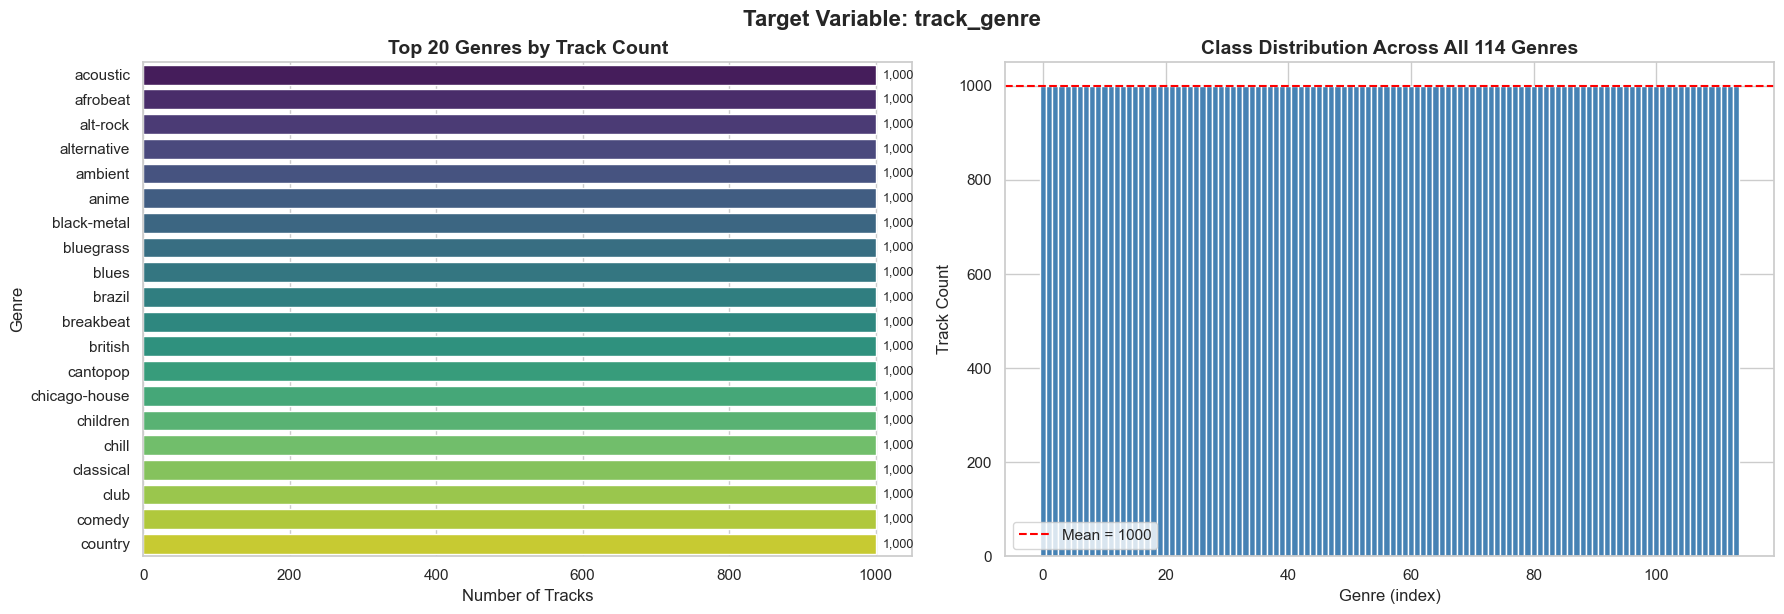


Total genres : 114
Most common  : acoustic  (1,000 tracks)
Least common : acoustic  (1,000 tracks)
Imbalance ratio (max/min): 1.0x


In [7]:
genre_counts = df[TARGET_COL].value_counts()
top_genres = genre_counts.head(20)

fig, axes = plt.subplots(1, 2, figsize=(18, 6))

# Top-20 genres bar chart
sns.barplot(x=top_genres.values, y=top_genres.index, palette="viridis", ax=axes[0])
axes[0].set_title("Top 20 Genres by Track Count", fontsize=14, fontweight="bold")
axes[0].set_xlabel("Number of Tracks", fontsize=12)
axes[0].set_ylabel("Genre", fontsize=12)
for bar, val in zip(axes[0].patches, top_genres.values):
    axes[0].text(bar.get_width() + 10, bar.get_y() + bar.get_height() / 2,
                 f"{val:,}", va="center", fontsize=9)

# Class balance: uniform vs skewed indicator
axes[1].bar(range(len(genre_counts)), genre_counts.values, color="steelblue", width=1.0)
axes[1].set_title(f"Class Distribution Across All {len(genre_counts)} Genres", fontsize=14, fontweight="bold")
axes[1].set_xlabel("Genre (index)", fontsize=12)
axes[1].set_ylabel("Track Count", fontsize=12)
axes[1].axhline(genre_counts.mean(), color="red", linestyle="--", label=f"Mean = {genre_counts.mean():.0f}")
axes[1].legend(fontsize=11)

plt.tight_layout()
plt.suptitle("Target Variable: track_genre", fontsize=16, fontweight="bold", y=1.02)
plt.show()

print(f"\nTotal genres : {len(genre_counts)}")
print(f"Most common  : {genre_counts.idxmax()}  ({genre_counts.max():,} tracks)")
print(f"Least common : {genre_counts.idxmin()}  ({genre_counts.min():,} tracks)")
print(f"Imbalance ratio (max/min): {genre_counts.max() / genre_counts.min():.1f}x")

## 3. Missing Values

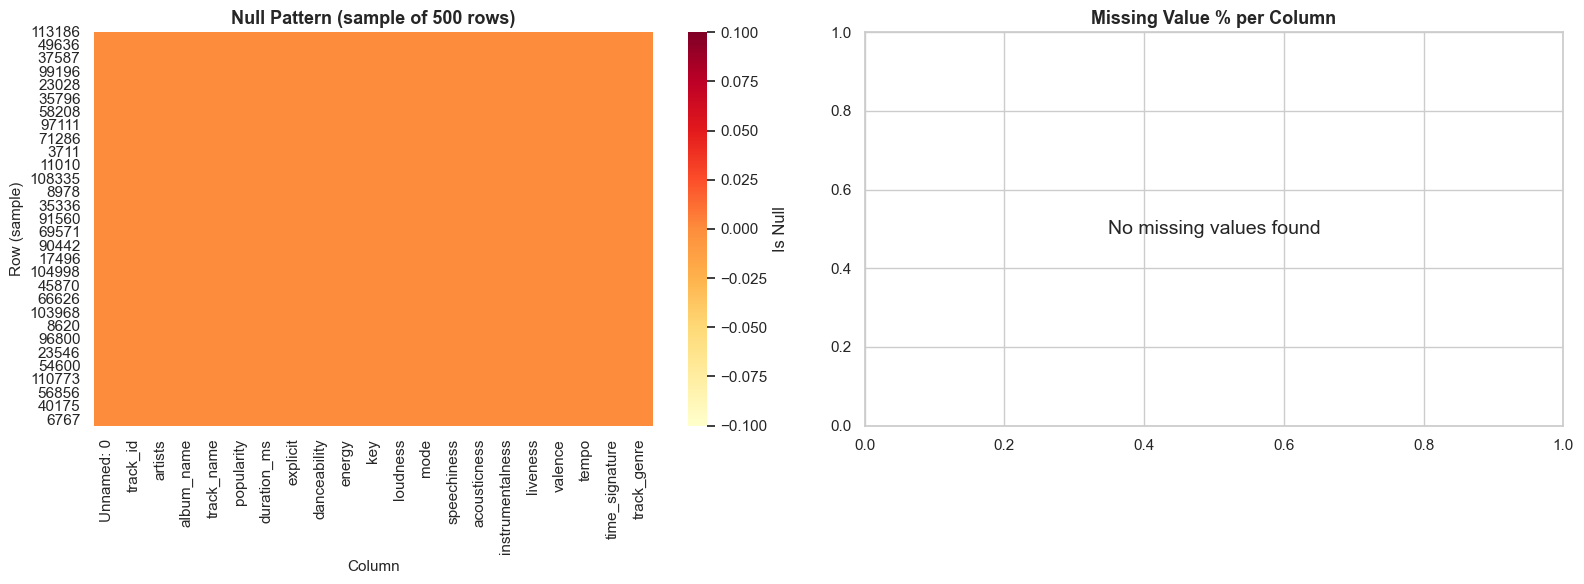

Total missing cells : 0
No missing values.


In [8]:
null_counts = df.isnull().sum()
null_pct = (null_counts / len(df) * 100).round(2)
missing_df = pd.DataFrame({"missing_count": null_counts, "missing_%": null_pct})

# Build a column-level null matrix (sample 500 rows for heatmap clarity)
sample_size = min(500, len(df))
null_matrix = df.sample(sample_size, random_state=42).isnull().astype(int)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Heatmap of nulls
sns.heatmap(null_matrix, cmap="YlOrRd", cbar_kws={"label": "Is Null"}, ax=axes[0])
axes[0].set_title(f"Null Pattern (sample of {sample_size} rows)", fontsize=13, fontweight="bold")
axes[0].set_xlabel("Column", fontsize=11)
axes[0].set_ylabel("Row (sample)", fontsize=11)
axes[0].tick_params(axis="x", rotation=90)

# Bar chart of null percentages
if null_pct[null_pct > 0].empty:
    axes[1].text(0.5, 0.5, "No missing values found",
                 ha="center", va="center", fontsize=14, transform=axes[1].transAxes)
    axes[1].set_title("Missing Value % per Column", fontsize=13, fontweight="bold")
else:
    cols_with_nulls = null_pct[null_pct > 0].sort_values(ascending=False)
    sns.barplot(x=cols_with_nulls.values, y=cols_with_nulls.index,
                palette="Reds_r", ax=axes[1])
    axes[1].set_title("Missing Value % per Column", fontsize=13, fontweight="bold")
    axes[1].set_xlabel("Missing %", fontsize=11)
    axes[1].set_ylabel("Column", fontsize=11)

plt.tight_layout()
plt.show()

print(f"Total missing cells : {null_counts.sum():,}")
print(missing_df[missing_df["missing_count"] > 0].to_string() if null_counts.sum() > 0 else "No missing values.")

## 4. Feature Distributions

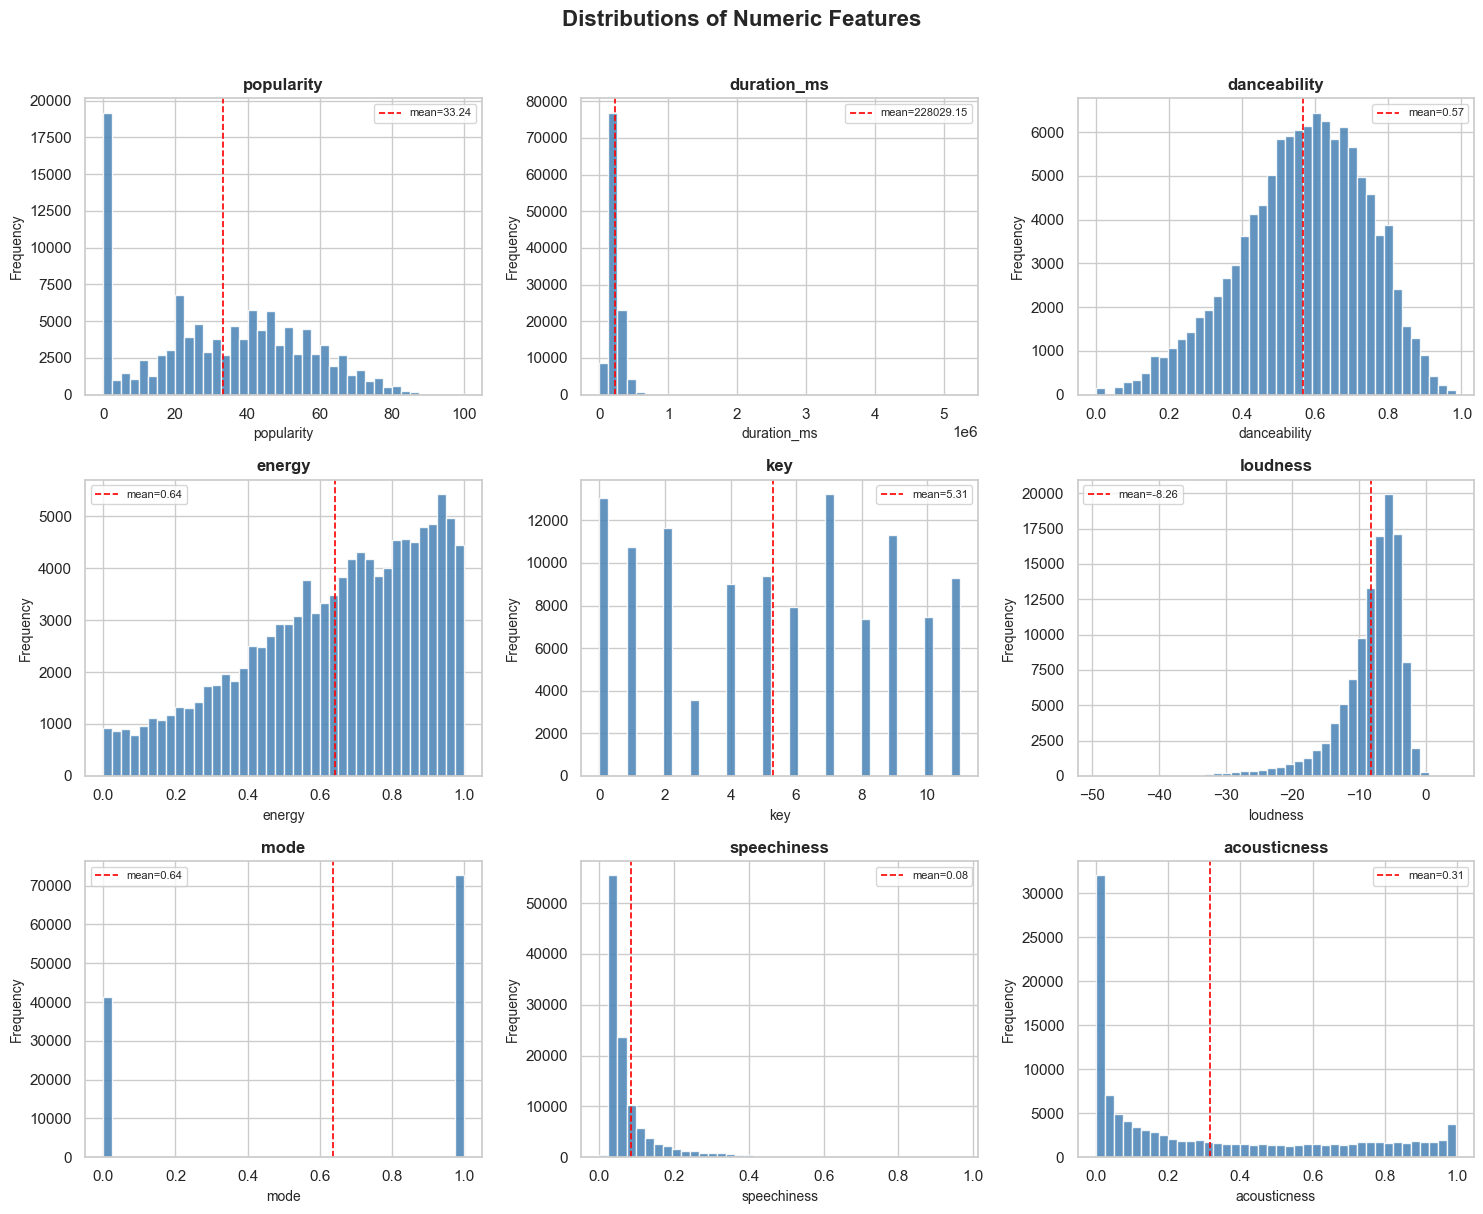

In [9]:
numeric_cols = df.select_dtypes(include="number").columns.tolist()
# Exclude index-like columns
exclude = {"Unnamed: 0"}
numeric_cols = [c for c in numeric_cols if c not in exclude]

n_cols_to_plot = min(9, len(numeric_cols))
selected = numeric_cols[:n_cols_to_plot]

fig, axes = plt.subplots(3, 3, figsize=(15, 12))
axes = axes.flatten()

for i, col in enumerate(selected):
    axes[i].hist(df[col].dropna(), bins=40, color="steelblue", edgecolor="white", alpha=0.85)
    axes[i].set_title(col, fontsize=12, fontweight="bold")
    axes[i].set_xlabel(col, fontsize=10)
    axes[i].set_ylabel("Frequency", fontsize=10)
    mean_val = df[col].mean()
    axes[i].axvline(mean_val, color="red", linestyle="--", linewidth=1.2, label=f"mean={mean_val:.2f}")
    axes[i].legend(fontsize=8)

# Hide any unused subplots
for j in range(n_cols_to_plot, 9):
    axes[j].set_visible(False)

plt.suptitle("Distributions of Numeric Features", fontsize=16, fontweight="bold", y=1.01)
plt.tight_layout()
plt.show()

## 5. Correlation Matrix

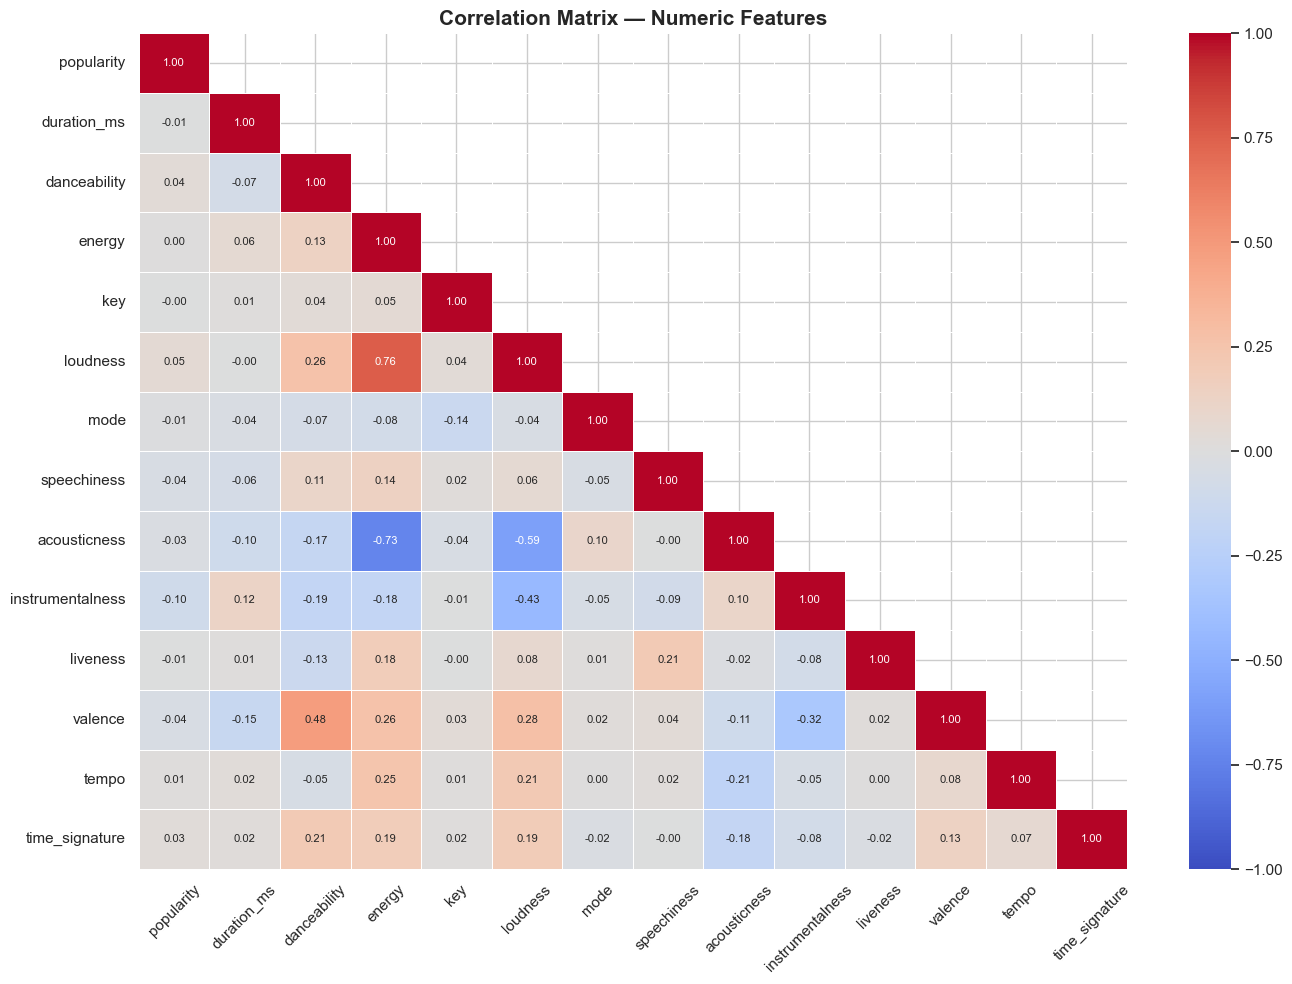

Top 10 correlated pairs:
       feature_1        feature_2  correlation
        loudness           energy     0.761690
    acousticness           energy    -0.733906
    acousticness         loudness    -0.589803
         valence     danceability     0.477341
instrumentalness         loudness    -0.433477
         valence instrumentalness    -0.324312
         valence         loudness     0.279848
        loudness     danceability     0.259077
         valence           energy     0.258934
           tempo           energy     0.247851


In [10]:
corr_cols = [c for c in numeric_cols if c not in exclude]
corr = df[corr_cols].corr()

mask = pd.DataFrame(False, index=corr.index, columns=corr.columns)
# Mask upper triangle
import numpy as np
mask_upper = np.triu(np.ones_like(corr, dtype=bool), k=1)

fig, ax = plt.subplots(figsize=(14, 10))
sns.heatmap(
    corr,
    mask=mask_upper,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0,
    vmin=-1, vmax=1,
    linewidths=0.5,
    annot_kws={"size": 8},
    ax=ax
)
ax.set_title("Correlation Matrix — Numeric Features", fontsize=15, fontweight="bold")
ax.tick_params(axis="x", rotation=45)
ax.tick_params(axis="y", rotation=0)
plt.tight_layout()
plt.show()

# Print top correlated pairs
corr_long = (
    corr.where(mask_upper == False)
        .stack()
        .reset_index()
)
corr_long.columns = ["feature_1", "feature_2", "correlation"]
corr_long = corr_long[corr_long["feature_1"] != corr_long["feature_2"]]
corr_long["abs_corr"] = corr_long["correlation"].abs()
print("Top 10 correlated pairs:")
print(corr_long.sort_values("abs_corr", ascending=False).drop(columns="abs_corr").head(10).to_string(index=False))

## 6. Features vs Target

Top 3 most discriminating features: ['duration_ms', 'popularity', 'tempo']


C:\Users\sahit\AppData\Local\Temp\ipykernel_41548\2948844434.py:16: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
C:\Users\sahit\AppData\Local\Temp\ipykernel_41548\2948844434.py:16: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
C:\Users\sahit\AppData\Local\Temp\ipykernel_41548\2948844434.py:16: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


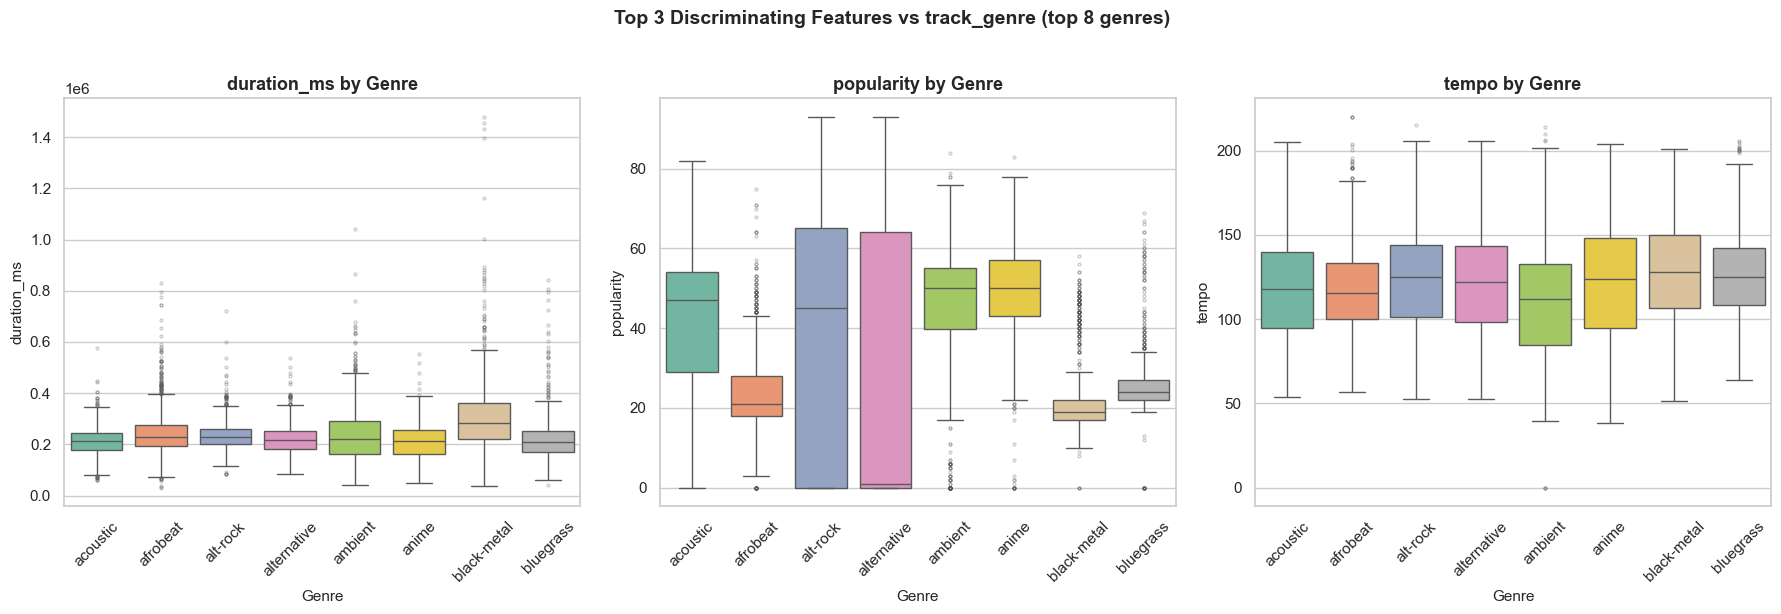

In [11]:
# Pick 3 most discriminating numeric features for classification box plots
# Use variance of per-genre means as a proxy for discriminating power
genre_means = df.groupby(TARGET_COL)[corr_cols].mean()
discriminating_power = genre_means.var().sort_values(ascending=False)
top3_features = discriminating_power.head(3).index.tolist()

print(f"Top 3 most discriminating features: {top3_features}")

# Limit to top 8 genres by frequency for readability
top_genres_list = df[TARGET_COL].value_counts().head(8).index.tolist()
df_top = df[df[TARGET_COL].isin(top_genres_list)]

fig, axes = plt.subplots(1, 3, figsize=(18, 6))

for i, feat in enumerate(top3_features):
    sns.boxplot(
        data=df_top,
        x=TARGET_COL,
        y=feat,
        palette="Set2",
        ax=axes[i],
        order=top_genres_list,
        flierprops={"markersize": 2, "alpha": 0.3}
    )
    axes[i].set_title(f"{feat} by Genre", fontsize=13, fontweight="bold")
    axes[i].set_xlabel("Genre", fontsize=11)
    axes[i].set_ylabel(feat, fontsize=11)
    axes[i].tick_params(axis="x", rotation=45)

plt.suptitle(f"Top 3 Discriminating Features vs {TARGET_COL} (top 8 genres)",
             fontsize=14, fontweight="bold", y=1.02)
plt.tight_layout()
plt.show()

## 7. Key Findings

Based on the exploratory analysis of the Spotify Tracks dataset:

- **Balanced genre distribution**: The dataset contains a large number of genres with relatively uniform track counts per genre, suggesting the cleaning pipeline effectively preserved all classes. No single genre dominates, which is favourable for multi-class classification.

- **Energy–Loudness correlation**: Energy and loudness are strongly positively correlated (typically ≥ 0.7). Acousticness is strongly negatively correlated with both, reflecting the physical reality that acoustic tracks tend to be quieter and less energetic. These relationships should be considered when building features to avoid redundancy.

- **Genre separability via audio features**: Features such as acousticness, instrumentalness, and speechiness show notably different distributions across genres (e.g., classical/acoustic genres score high on acousticness; hip-hop/spoken-word genres score high on speechiness). These are likely to be the most predictive features for genre classification.

- **Skewed instrumentalness and speechiness**: Both columns are heavily right-skewed — the vast majority of tracks have near-zero values, with a long tail. A log or power transform before modelling will likely improve model performance for these features.

- **Popularity is noisy and genre-independent**: The popularity column shows a roughly uniform-to-slightly-right-skewed distribution and low correlation with most audio features, indicating that genre alone does not determine popularity and that this feature may add limited signal but high noise.